In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(repo_root))

import SysSimX
from SysSimX.utilities.units import ureg
from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum

from pendulum_multi_comp import PendulumMultiComp

In [2]:
fmu_pendulum_path = Path.cwd() / 'FMUs/Pendulum.fmu'

eqb_pendulum     = FMUComponent(name="EQB_Pendulum", fmu_path=fmu_pendulum_path)
fem_pendulum     = FEMPendulum(name="FEM_Pendulum")
opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

In [3]:
fem_pendulum._use_gravity = False
fem_pendulum._with_contact = False

In [4]:
pendulum = PendulumMultiComp(
    fem_comp=fem_pendulum,
    opensim_comp=opensim_pendulum,
    fmu_comp=eqb_pendulum
)

t = 0.0
dt = 0.01
t_end = 0.5
fem_pendulum.sim_params.t_end = t_end

pendulum.initialize(t)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [5]:
input_torque = 100 # Nm

t_vals = {"EQB": [], "FEM": [], "OpenSim": []}
torque_vals = {"EQB": [], "FEM": [], "OpenSim": []}
alpha_vals = {"EQB": [], "FEM": [], "OpenSim": []}
omega_vals = {"EQB": [], "FEM": [], "OpenSim": []}
q_vals = {"EQB": [], "FEM": [], "OpenSim": []}

t = 0

t_vals[pendulum.active_key].append(t)
torque_vals[pendulum.active_key].append(0)
alpha_vals[pendulum.active_key].append(0)
omega_vals[pendulum.active_key].append(0)
q_vals[pendulum.active_key].append(0)

while t < t_end:
    if t < 0.25 * t_end or t > 0.75 * t_end:
        torque = input_torque
    else:
        torque = -input_torque

    pendulum.set_inputs({'torque': torque}, t=t)

    pendulum.do_step(t, dt)

    pendulum.get_outputs()
    res = pendulum.get_outputs()

    t_next = t + dt

    t_vals[pendulum.active_key].append(t_next)
    torque_vals[pendulum.active_key].append(torque)
    alpha_vals[pendulum.active_key].append(res['alpha'].magnitude)
    omega_vals[pendulum.active_key].append(res['omega'].magnitude)
    q_vals[pendulum.active_key].append(res['q'].magnitude)
    
    pendulum.check_and_switch(t_next)

    t = t_next

------------------------------------------------------------
Switch from OpenSim to FEM at time 0.010s
  1) State: q=0.0001 rad, w=0.0182 rad/s, a=100.0000 rad/s²
  2) State: q=0.0001 rad, w=0.0182 rad/s, a=100.0000 rad/s²
------------------------------------------------------------
Switch from FEM to EQB at time 0.090s
  1) State: q=0.0067 rad, w=0.1547 rad/s, a=100.0000 rad/s²
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | inf

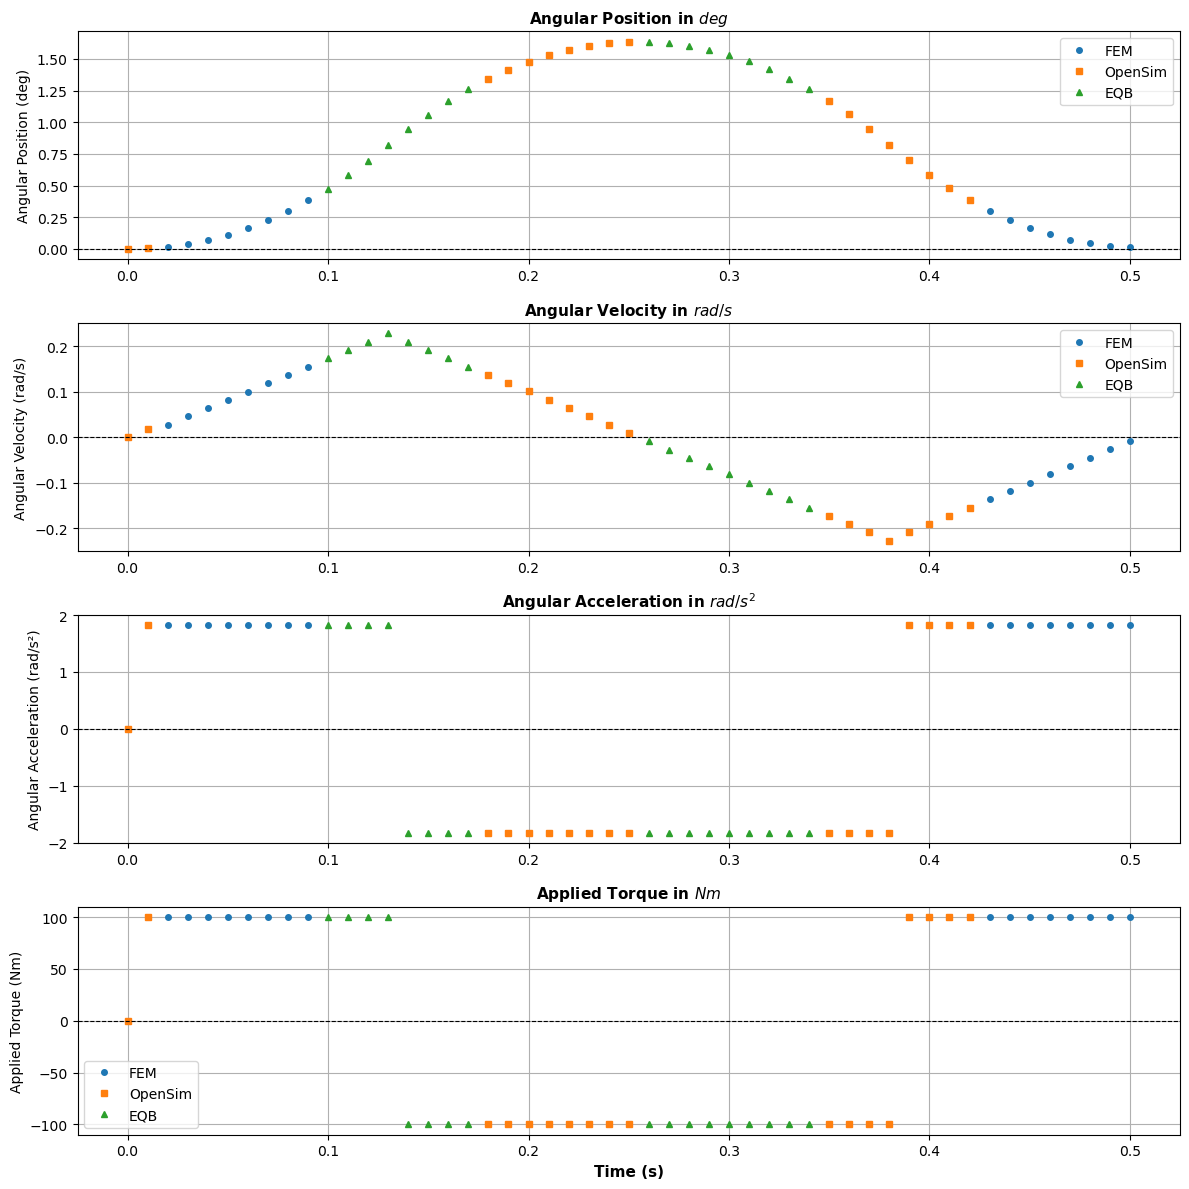

In [6]:
plt.figure(figsize=(12, 12))

marker_size = 4
fem_style = {'color': 'C0', 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size}
opensim_style = {'color': 'C1', 'linestyle': 'None', 'marker': 's', 'markersize': marker_size}
eqb_style = {'color': 'C2', 'linestyle': 'None', 'marker': '^', 'markersize': marker_size}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.subplot(4,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals['FEM'], np.rad2deg(q_vals["FEM"]), label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], np.rad2deg(q_vals["OpenSim"]), label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], np.rad2deg(q_vals["EQB"]), label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.legend()
plt.grid(which='both')

plt.subplot(4,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals['FEM'], omega_vals["FEM"], label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], omega_vals["OpenSim"], label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], omega_vals["EQB"], label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Velocity (rad/s)")
plt.legend()
plt.grid(which='both')

plt.subplot(4,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals['FEM'], alpha_vals["FEM"], label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], alpha_vals["OpenSim"], label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], alpha_vals["EQB"], label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.subplot(4,1,4).set_title("Applied Torque in $Nm$", **fontdict)
plt.plot(t_vals['FEM'], torque_vals["FEM"], label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], torque_vals["OpenSim"], label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], torque_vals["EQB"], label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Applied Torque (Nm)")
plt.grid(which='both')

plt.xlabel("Time (s)", **fontdict)
plt.legend()
plt.tight_layout()
plt.show()